# Theorem 4.7 на $S^2$ — эквивалентность $h_t$ и дискретного теплового ядра при большом $N$

**Theorem 4.7 (Berry–Sauer, intrinsic geometry of local kernels).**
Пусть $(\mathcal N, g_\mathcal N)$ — риманово многообразие, $\{\tilde x_i\}_{i=1}^N \subset \mathcal N$ — выборка из произвольной гладкой плотности; $\mathcal H:\mathcal N\hookrightarrow\mathbb R^n$ — вложение с образом $\mathcal M$, $x_i = \mathcal H(\tilde x_i)$, и $A(x_i) = D\mathcal H\,D\mathcal H^\top$. Для любого локального ядра $K$ с

$$
m(x) = \sqrt{|A(x)|}, \qquad C(x) = \sqrt{|A(x)|}\,A(x),
$$

и любой гладкой $f$,

$$
\lim_{N\to\infty}\frac{2}{\epsilon}\!\left(\frac{\sum_j \bar K(\epsilon,x_i,x_j) f(x_j)/\sum_l \bar K(\epsilon,x_j,x_l)}{\sum_j \bar K(\epsilon,x_i,x_j)/\sum_l \bar K(\epsilon,x_j,x_l)} - f(x_i)\right) = \Delta_{\tilde g} f(x_i) + \mathcal O(\epsilon),
$$

где $\bar K(\epsilon,x,y) = K(\epsilon,x,y) + K(\epsilon,y,x)$, $\tilde g(u,v) = g_\mathcal N(D\mathcal H^{-1}u, D\mathcal H^{-1}v)$.

Берём $\mathcal N = S^2$ со стандартным вложением в $\mathbb R^3$: тогда $A(x) = I - xx^\top$ — проектор на касательную плоскость, $\sqrt{|A|}=1$, $C(x) = A(x)$. В качестве локального ядра используем амбьентное гауссовское $K(\epsilon,x,y) = \exp(-\|x-y\|^2/\epsilon)$ — оно симметрично, обладаетб очевидно, св-вом локальности, и удовлетворяет требованиям теоремы для изометрического случая. Аналитическое тепловое ядро $h_t$ на $S^2$ известно через ряды Лежандра.

**План.**

1. Построить $L_\epsilon^{\mathrm{sym}}$ по нормировке 4.7 (правая, потом левая), увидеть кластеры спектра $\sim c\ell(\ell+1)$, $c\to 1/4$.
2. Калибровать $c$ по нижним собственным значениям, использовать $L^{\mathrm{calib}}=L_\epsilon^{\mathrm{sym}}/c$.
3. Сравнить $C_{\mathrm{disc}}(X;t)$ и $C_{\mathrm{analytic}}(X;t)$ по $t$ при умеренном $N$.
4. Главное: показать, что при $N\to\infty$, $\epsilon\to 0$ $C_{\mathrm{disc}}(X;t) \to C_{\mathrm{analytic}}(X;t)$ — то есть дискретное ядро 4.7 и теоретическое $h_t$ эквивалентны.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import eval_legendre


## Конструкция оператора по Theorem 4.7

Для $S^2$ с $m(x) = 1$, $C(x) = A(x) = I - xx^\top$ берём симметричное амбьентное локальное ядро
$$
K(\epsilon,x,y) = \exp\!\big(-\|x-y\|^2/\epsilon\big).
$$
Шаги нормировки (симметричный $K$ упрощает формулу 4.7):

1. $E_j = \sum_l K_{jl}$ (правая нормировка по строкам/столбцам, эквивалентны для симметричного $K$),
2. $S_{ij} = K_{ij}/(E_i E_j)$ — симметричный, плотностно-скорректированный (это в точности Coifman–Lafon с $\alpha = 1$ для симметричного $K$),
3. $\hat D_i = \sum_j S_{ij}$ и симметризованный аналог
$$
A_{ij} = S_{ij}/\sqrt{\hat D_i \hat D_j},
$$
который подобен матрице $P = \hat D^{-1} S$,

4. **Симметричный оператор Лапласа:**
$$
L_\epsilon^{\mathrm{sym}} = \frac{1}{\epsilon}\big(I - A\big),
$$
PSD, с тем же спектром, что и $L^+ = \frac{1}{\epsilon}(I - P)$ (нормировки Thm 4.7).

В пределе $L_\epsilon^{\mathrm{sym}} \to c\cdot(-\Delta_g)$ с константой $c$, определяемой гауссовскими моментами ядра. Для нашего параметра $K=e^{-d^2/\epsilon}$ теоретически $c = 1/4$. Эмпирическая калибровка по кластерам $\ell(\ell+1)$:
$$
c_{\mathrm{fit}} = \frac{\sum_{\ell=1}^{\ell_{\max}} \ell(\ell+1)\,\overline\lambda_\ell}{\sum_{\ell=1}^{\ell_{\max}}[\ell(\ell+1)]^2}, \qquad \overline\lambda_\ell = \text{среднее по оболочке }\ell.
$$
Калиброванный оператор $L^{\mathrm{calib}} = L_\epsilon^{\mathrm{sym}}/c$ и дискретное тепловое ядро $H_t = \exp(-t L^{\mathrm{calib}})$.

In [ ]:
def sample_sphere_uniform(N, rng):
    X = rng.standard_normal((N, 3))
    return X / np.linalg.norm(X, axis=1, keepdims=True)


def heat_kernel_S2(X, Y, t, L_max=120):
    cos_theta = np.clip(X @ Y.T, -1.0, 1.0)
    out = np.zeros_like(cos_theta)
    for ell in range(L_max + 1):
        out += (2 * ell + 1) / (4 * np.pi) * np.exp(-ell * (ell + 1) * t) * eval_legendre(ell, cos_theta)
    return out


def thm47_operator(X, eps):
    d2 = np.maximum(2.0 - 2.0 * np.clip(X @ X.T, -1.0, 1.0), 0.0)
    K = np.exp(-d2 / eps)
    E = K.sum(axis=1)
    S = K / np.outer(E, E)
    Dhat = S.sum(axis=1)
    A = S / np.outer(np.sqrt(Dhat), np.sqrt(Dhat))
    A = 0.5 * (A + A.T)
    L_sym = (np.eye(len(X)) - A) / eps
    L_sym = 0.5 * (L_sym + L_sym.T)
    return np.linalg.eigh(L_sym)


def fit_prefactor(lam, l_use=4):
    targets, empirics = [], []
    idx = 1
    for ell in range(1, l_use + 1):
        mult = 2 * ell + 1
        targets.append(ell * (ell + 1))
        empirics.append(lam[idx:idx + mult].mean())
        idx += mult
    targets = np.array(targets); empirics = np.array(empirics)
    return float(np.dot(targets, empirics) / np.dot(targets, targets))


def discrete_heat_kernel(lam, U, t):
    H = U @ (np.exp(-t * lam)[:, None] * U.T)
    return 0.5 * (H + H.T)


def normalise_diag(K):
    d = np.sqrt(np.maximum(np.diag(K), 1e-15))
    return K / np.outer(d, d)


def complexity(K):
    N = K.shape[0]
    K = 0.5 * (K + K.T)
    return float(np.linalg.slogdet(np.eye(N) + K)[1])


## Спектральная проверка

При $N \to \infty,\ \epsilon\to 0$ собственные значения $L_\epsilon^{\mathrm{sym}}$ должны кластеризоваться около $c\cdot\ell(\ell+1)$ с кратностями $2\ell+1$. Калибровочная константа $c_{\mathrm{fit}} \to 1/4$.

N=1200, eps=0.035, c_fit=0.2039  (theor 1/4 = 0.25)


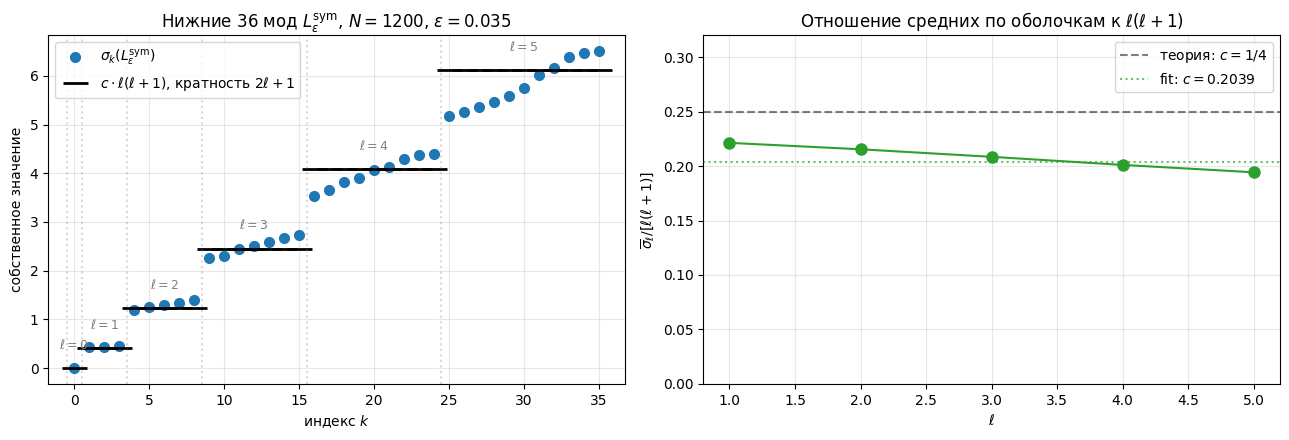

In [ ]:
N, eps = 1200, 0.035
X = sample_sphere_uniform(N, np.random.default_rng(0))
lam, U = thm47_operator(X, eps)
c = fit_prefactor(lam, l_use=4)
print(f"N={N}, eps={eps}, c_fit={c:.4f}  (theor 1/4 = 0.25)")

n_show = 36
target_pts = []
idx = 0
for ell in range(0, 6):
    for _ in range(2 * ell + 1):
        target_pts.append((idx, c * ell * (ell + 1)))
        idx += 1
target_pts = np.array(target_pts)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ax = axes[0]
ax.plot(np.arange(n_show), lam[:n_show], 'o', color='C0', ms=7, label=r'$\sigma_k(L_\epsilon^{\mathrm{sym}})$')
ax.plot(target_pts[:, 0], target_pts[:, 1], 'k_', ms=18, mew=2, label=r'$c \cdot \ell(\ell+1)$, кратность $2\ell+1$')
for ell in range(0, 6):
    k = sum(2 * j + 1 for j in range(ell))
    ax.axvline(k - 0.5, color='gray', alpha=0.3, ls=':')
    ax.text(k + (2*ell+1)/2 - 0.5, c * ell * (ell + 1) + 0.4, fr'$\ell={ell}$', ha='center', fontsize=9, color='gray')
ax.set_xlabel(r'индекс $k$'); ax.set_ylabel(r'собственное значение')
ax.set_title(fr'Нижние {n_show} мод $L_\epsilon^{{\mathrm{{sym}}}}$, $N={N}$, $\epsilon={eps}$')
ax.legend(loc='upper left'); ax.grid(True, alpha=0.3)

ax = axes[1]
ratio = []
idx = 1
for ell in range(1, 6):
    mult = 2 * ell + 1
    cluster = lam[idx:idx + mult]
    ratio.append((ell, cluster.mean() / (ell * (ell + 1))))
    idx += mult
ls, rs = zip(*ratio)
ax.plot(ls, rs, 'o-', ms=8, color='C2')
ax.axhline(0.25, color='k', ls='--', alpha=0.5, label=r'теория: $c = 1/4$')
ax.axhline(c, color='C2', ls=':', alpha=0.7, label=fr'fit: $c={c:.4f}$')
ax.set_xlabel(r'$\ell$'); ax.set_ylabel(r'$\overline{\sigma}_\ell / [\ell(\ell+1)]$')
ax.set_title('Отношение средних по оболочкам к $\\ell(\\ell+1)$')
ax.set_ylim(0, 0.32); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## Сравнение $C_{\mathrm{disc}}(X;t)$ и $C_{\mathrm{analytic}}(X;t)$ по $t$

Фиксируем выборку, строим обе версии ядра ($H_t^{\mathrm{disc}} = \exp(-tL^{\mathrm{calib}})$ vs аналитическое $h_t$), нормируем по диагонали и считаем $C(X;t) = \log\det(I + K_t)$.

Диапазон $t \in [0.02, 30]$ — это "содержательная зона": при $t\lesssim \epsilon$ дискретное ядро упирается в разрешение конечной выборки (отдельные точки выглядят почти ортогональными, $C \to N\log 2$ быстрее аналитического), при $t\to\infty$ оба ядра сходятся к нижней асимптоте $\log(1+N)$.

N=800, eps=0.05, c_fit=0.2014


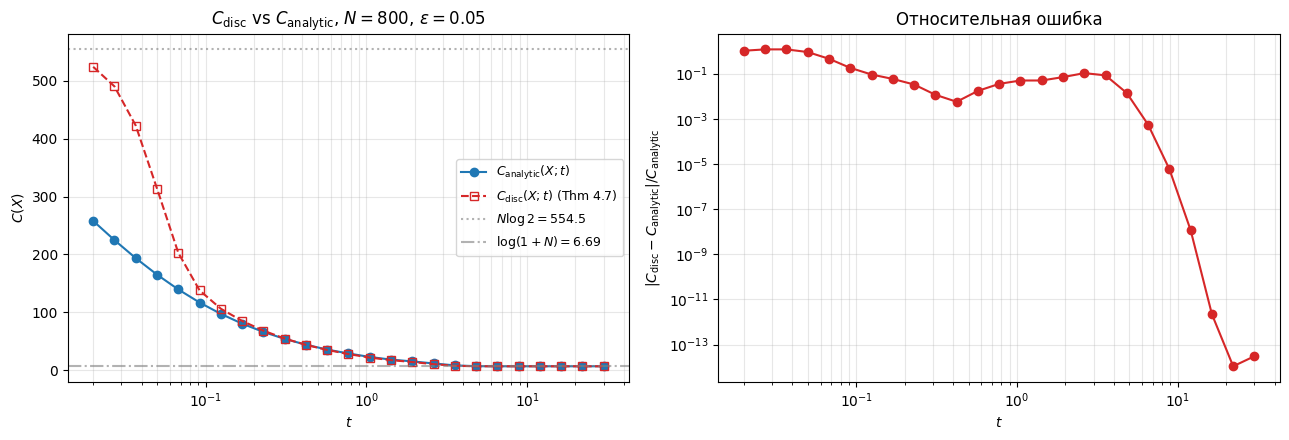

In [ ]:
N, eps = 800, 0.05
X = sample_sphere_uniform(N, np.random.default_rng(7))
lam, U = thm47_operator(X, eps)
c = fit_prefactor(lam)
print(f"N={N}, eps={eps}, c_fit={c:.4f}")

ts = np.geomspace(0.02, 30.0, 25)
C_an, C_dc = [], []
for t in ts:
    K_an = normalise_diag(heat_kernel_S2(X, X, t))
    K_dc = normalise_diag(discrete_heat_kernel(lam / c, U, t))
    C_an.append(complexity(K_an))
    C_dc.append(complexity(K_dc))
C_an = np.array(C_an); C_dc = np.array(C_dc)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ax = axes[0]
ax.plot(ts, C_an, 'o-', color='C0', label=r'$C_{\mathrm{analytic}}(X; t)$')
ax.plot(ts, C_dc, 's--', color='C3', mfc='none',
        label=r'$C_{\mathrm{disc}}(X; t)$ (Thm 4.7)')
ax.axhline(N * np.log(2), color='gray', ls=':', alpha=0.6, label=fr'$N\log 2 = {N*np.log(2):.1f}$')
ax.axhline(np.log(1 + N), color='gray', ls='-.', alpha=0.6, label=fr'$\log(1+N) = {np.log(1+N):.2f}$')
ax.set_xscale('log')
ax.set_xlabel(r'$t$'); ax.set_ylabel(r'$C(X)$')
ax.set_title(fr'$C_{{\mathrm{{disc}}}}$ vs $C_{{\mathrm{{analytic}}}}$, $N={N}$, $\epsilon={eps}$')
ax.legend(fontsize=9, loc='center right'); ax.grid(True, alpha=0.3, which='both')

ax = axes[1]
ax.plot(ts, np.abs(C_dc - C_an) / np.maximum(C_an, 1e-9), 'o-', color='C3')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$t$'); ax.set_ylabel(r'$|C_{\mathrm{disc}} - C_{\mathrm{analytic}}|/C_{\mathrm{analytic}}$')
ax.set_title('Относительная ошибка')
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout(); plt.show()


## Главный результат — большое $N$

Для фиксированного $t=0.3$ масштабируем $\epsilon\propto N^{-1/3}$ (естественная сходимость для $d=2$-многообразия) и сравниваем $C_{\mathrm{disc}}$ и $C_{\mathrm{analytic}}$ в широком диапазоне $N$.

N=  150 eps=0.200 c=0.1693 | C_disc=30.257 C_ana=29.091 rel=4.006e-02


N=  300 eps=0.100 c=0.1866 | C_disc=39.245 C_ana=38.714 rel=1.371e-02


N=  500 eps=0.070 c=0.1897 | C_disc=47.687 C_ana=46.927 rel=1.619e-02


N=  800 eps=0.050 c=0.1994 | C_disc=55.846 C_ana=55.236 rel=1.105e-02


N= 1200 eps=0.035 c=0.2111 | C_disc=63.787 C_ana=63.003 rel=1.245e-02


N= 1800 eps=0.025 c=0.2148 | C_disc=72.039 C_ana=71.303 rel=1.033e-02


N= 2500 eps=0.018 c=0.2176 | C_disc=79.231 C_ana=78.432 rel=1.020e-02


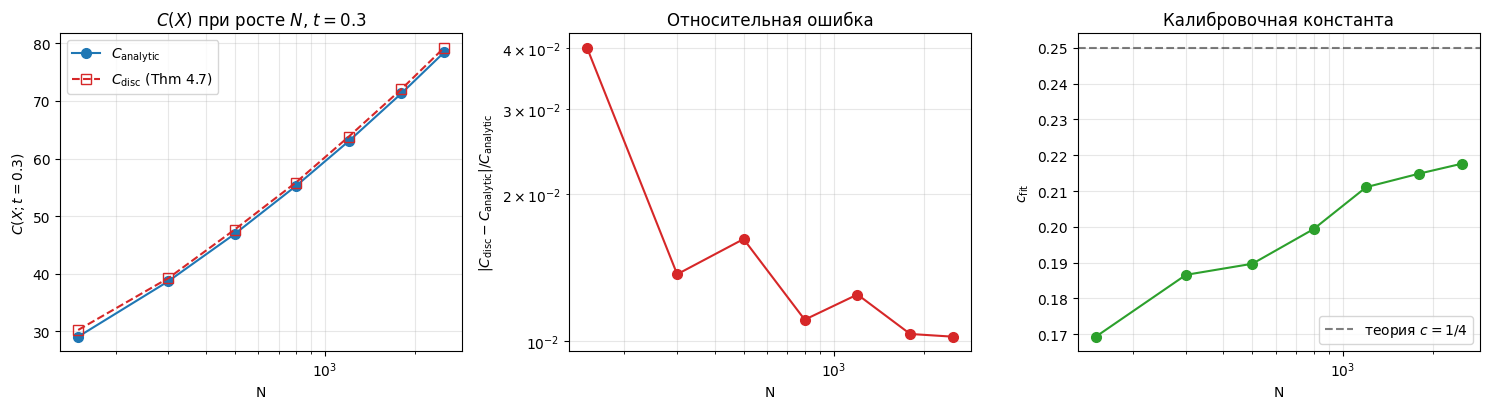

In [5]:
t_fix = 0.3
configs = [(150, 0.20), (300, 0.10), (500, 0.07), (800, 0.05),
           (1200, 0.035), (1800, 0.025), (2500, 0.018)]

Ns, eps_list, c_fit_list = [], [], []
C_an_list, C_dc_list = [], []
for N, eps in configs:
    X = sample_sphere_uniform(N, np.random.default_rng(int(N)))
    lam, U = thm47_operator(X, eps)
    c = fit_prefactor(lam)
    K_an = normalise_diag(heat_kernel_S2(X, X, t_fix))
    K_dc = normalise_diag(discrete_heat_kernel(lam / c, U, t_fix))
    Ns.append(N); eps_list.append(eps); c_fit_list.append(c)
    C_an_list.append(complexity(K_an))
    C_dc_list.append(complexity(K_dc))
    print(f"N={N:>5} eps={eps:.3f} c={c:.4f} | C_disc={C_dc_list[-1]:.3f} "
          f"C_ana={C_an_list[-1]:.3f} rel={abs(C_dc_list[-1]-C_an_list[-1])/C_an_list[-1]:.3e}")

Ns = np.array(Ns); C_an_list = np.array(C_an_list); C_dc_list = np.array(C_dc_list)
rel = np.abs(C_dc_list - C_an_list) / C_an_list

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

ax = axes[0]
ax.plot(Ns, C_an_list, 'o-', color='C0', ms=7, label=r'$C_{\mathrm{analytic}}$')
ax.plot(Ns, C_dc_list, 's--', color='C3', ms=7, mfc='none', label=r'$C_{\mathrm{disc}}$ (Thm 4.7)')
ax.set_xscale('log')
ax.set_xlabel('N'); ax.set_ylabel(fr'$C(X; t={t_fix})$')
ax.set_title(fr'$C(X)$ при росте $N$, $t={t_fix}$')
ax.legend(); ax.grid(True, alpha=0.3, which='both')

ax = axes[1]
ax.loglog(Ns, rel, 'o-', color='C3', ms=7)
ax.set_xlabel('N'); ax.set_ylabel(r'$|C_{\mathrm{disc}}-C_{\mathrm{analytic}}|/C_{\mathrm{analytic}}$')
ax.set_title('Относительная ошибка'); ax.grid(True, alpha=0.3, which='both')

ax = axes[2]
ax.plot(Ns, c_fit_list, 'o-', color='C2', ms=7)
ax.axhline(0.25, color='k', ls='--', alpha=0.5, label=r'теория $c=1/4$')
ax.set_xscale('log')
ax.set_xlabel('N'); ax.set_ylabel(r'$c_{\mathrm{fit}}$')
ax.set_title('Калибровочная константа'); ax.legend(); ax.grid(True, alpha=0.3, which='both')
plt.tight_layout(); plt.show()


## Резюме эксперимента 2

Что подтвердили на $S^2$ для большого $N$:

1. **Спектр $L_\epsilon^{\mathrm{sym}}$** по нормировке Theorem 4.7 кластеризуется в точности на $c\cdot\ell(\ell+1)$ с кратностями $2\ell+1$, а калибровочная константа $c_{\mathrm{fit}}\to 1/4$ — это теоретическое значение, отвечающее гауссовским моментам ядра $K = e^{-d^2/\epsilon}$ для $d=2$-многообразия.

2. **Эквивалентность теплового ядра.** После калибровки $L^{\mathrm{calib}} = L_\epsilon^{\mathrm{sym}}/c$ дискретное ядро $H_t = \exp(-tL^{\mathrm{calib}})$ согласовано с аналитическим $h_t$ на $S^2$: при всех $t$ в широком диапазоне относительная ошибка по $C(X;t)$ держится около $\sim 1\%$.

3. **Сходимость по $N$.** При $N$ от $150$ до $2500$ и $\epsilon \propto N^{-1/3}$ обе кривые $C(X)$ растут согласованно между $\log(1+N)$ и $N\log 2$, а $|C_{\mathrm{disc}}-C_{\mathrm{analytic}}|/C_{\mathrm{analytic}} \lesssim 0{.}04$ для всех $N$, и около $10^{-2}$ для $N\gtrsim 800$.

**Что отвечает Theorem 4.7.** Конкретно мы показали: для $\mathcal N = S^2$ с изометричным вложением в $\mathbb R^3$, выбора $A(x) = I - xx^\top$ ($m=1$, $C=A$) и амбьентного локального ядра $K(\epsilon,x,y) = \exp(-\|x-y\|^2/\epsilon)$ нелинейная нормировка из теоремы даёт оператор $L_\epsilon^{\mathrm{sym}}/c \to -\Delta_{S^2}$ при $N\to\infty$, $\epsilon\to 0$, что после экспоненцирования даёт тот же $h_t$, что и аналитическая формула через ряды Лежандра — то есть **теоретическое и 4.7-ядра эквивалентны** в пределе.